hyperparameter: degree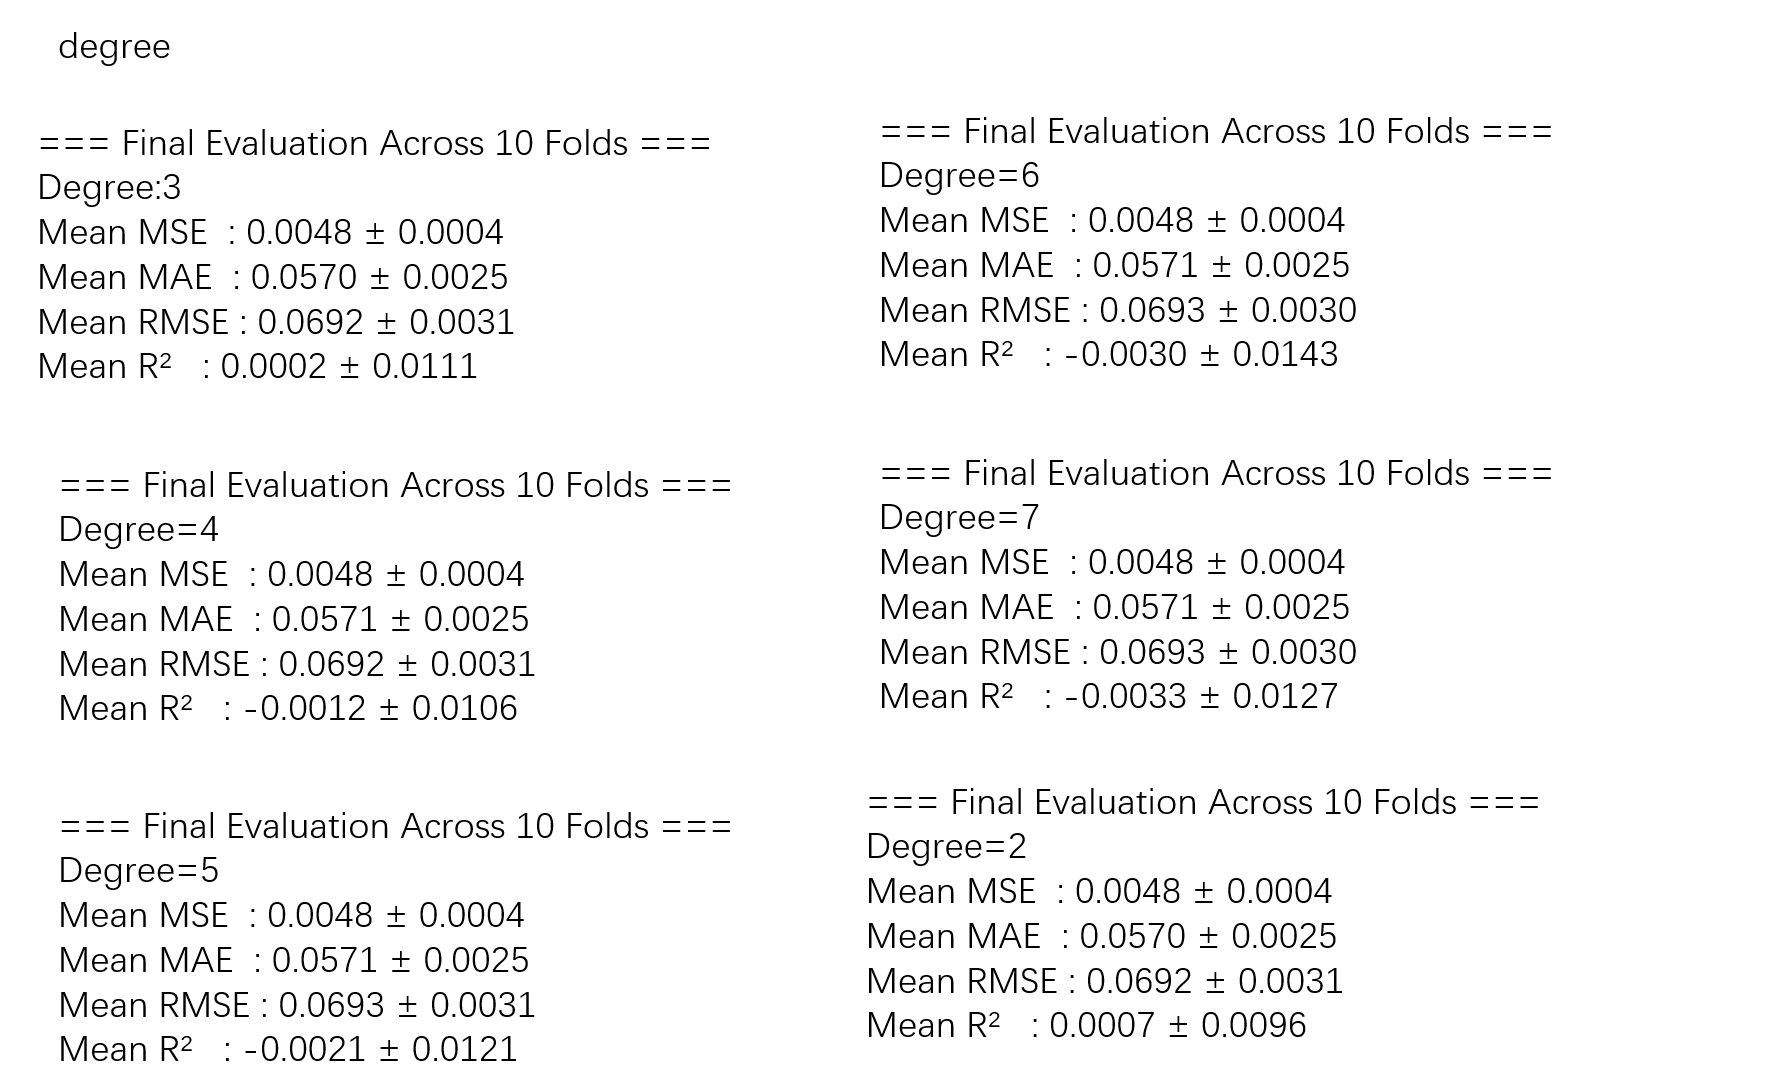


=== Fold 1 ===
MSE  : 0.0046
MAE  : 0.0565
RMSE : 0.0679
R²   : 0.0161


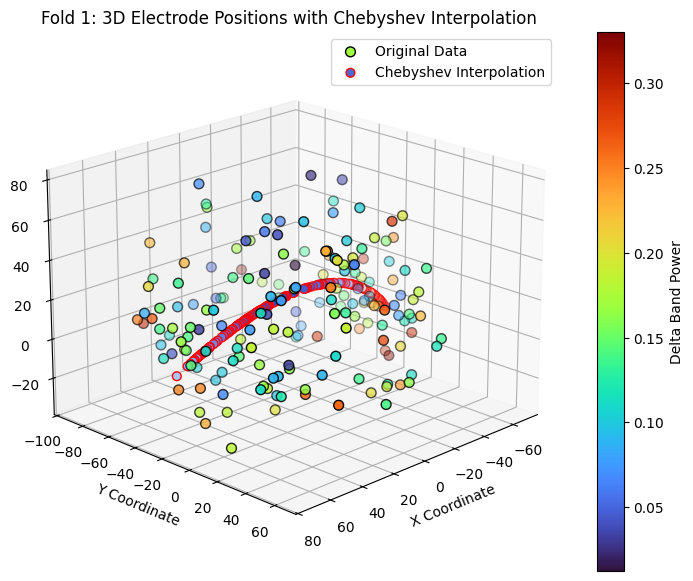


=== Fold 2 ===
MSE  : 0.0053
MAE  : 0.0593
RMSE : 0.0729
R²   : 0.0013


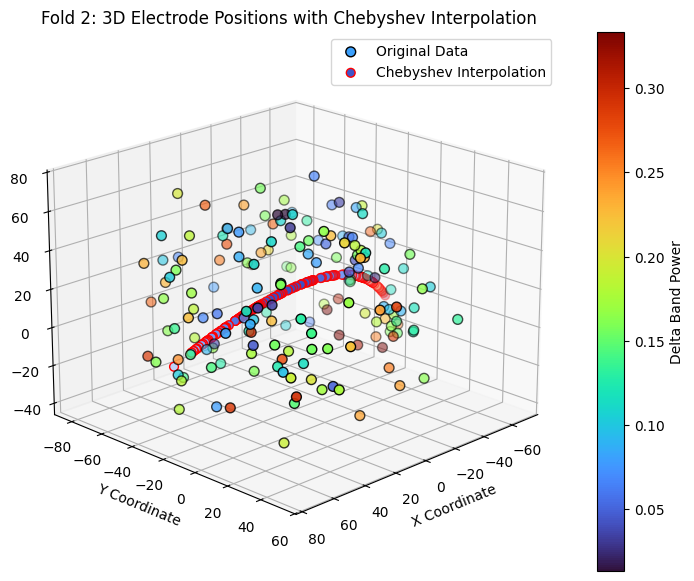


=== Fold 3 ===
MSE  : 0.0053
MAE  : 0.0606
RMSE : 0.0729
R²   : -0.0009


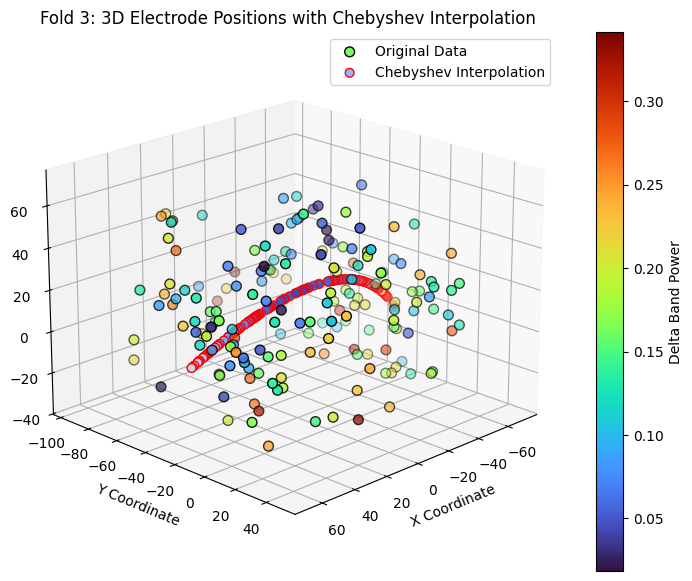


=== Fold 4 ===
MSE  : 0.0042
MAE  : 0.0530
RMSE : 0.0647
R²   : 0.0050


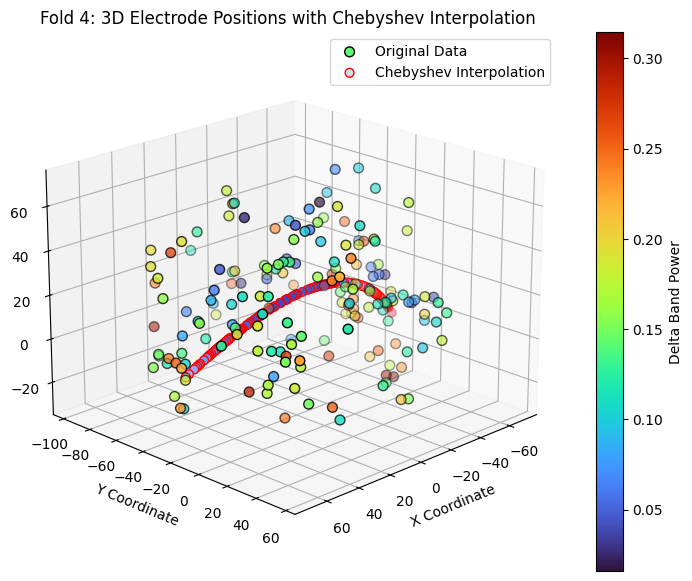


=== Fold 5 ===
MSE  : 0.0048
MAE  : 0.0559
RMSE : 0.0691
R²   : -0.0095


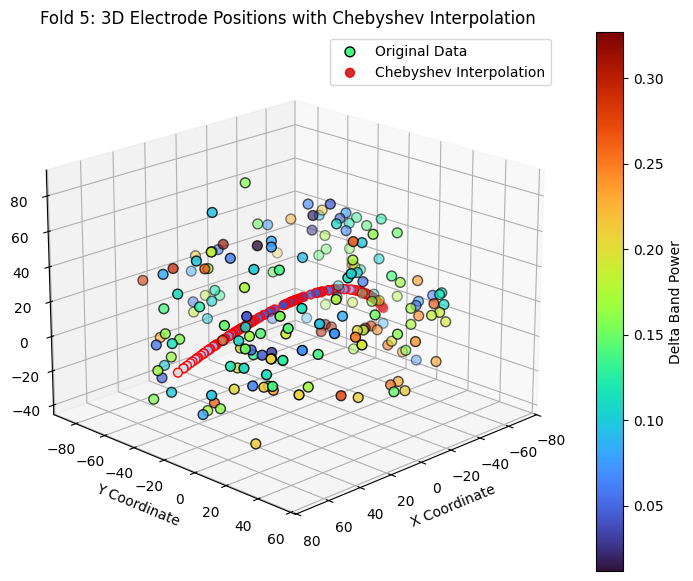


=== Fold 6 ===
MSE  : 0.0049
MAE  : 0.0581
RMSE : 0.0698
R²   : 0.0012


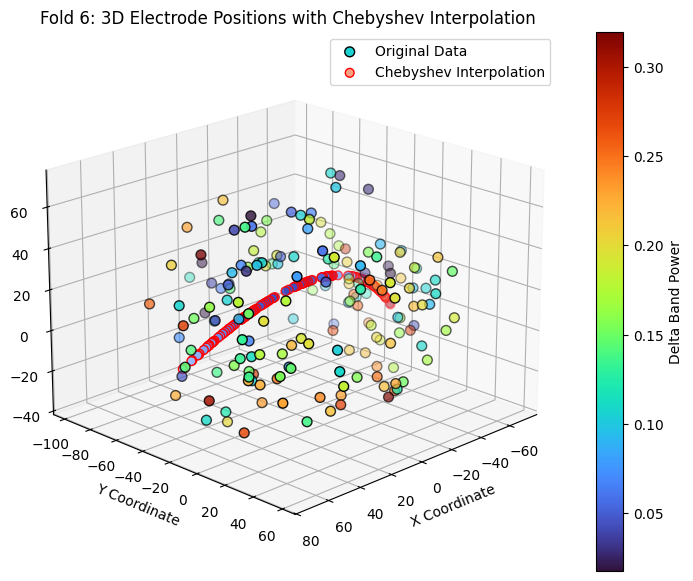


=== Fold 7 ===
MSE  : 0.0051
MAE  : 0.0590
RMSE : 0.0716
R²   : -0.0103


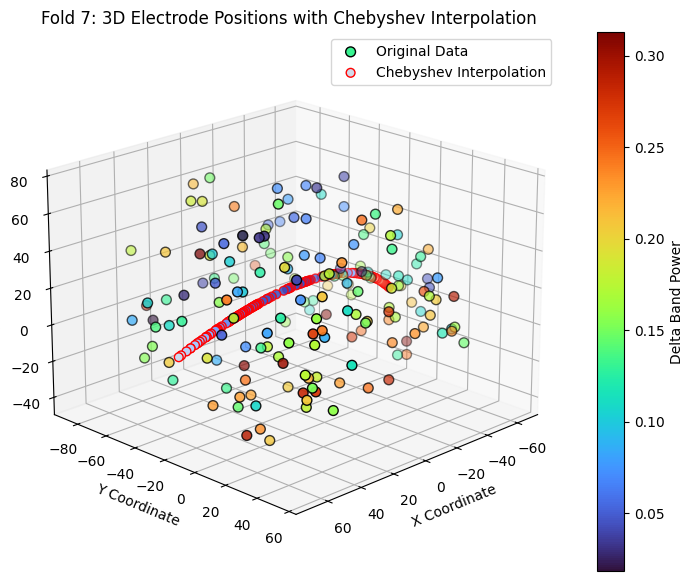


=== Fold 8 ===
MSE  : 0.0051
MAE  : 0.0583
RMSE : 0.0711
R²   : 0.0123


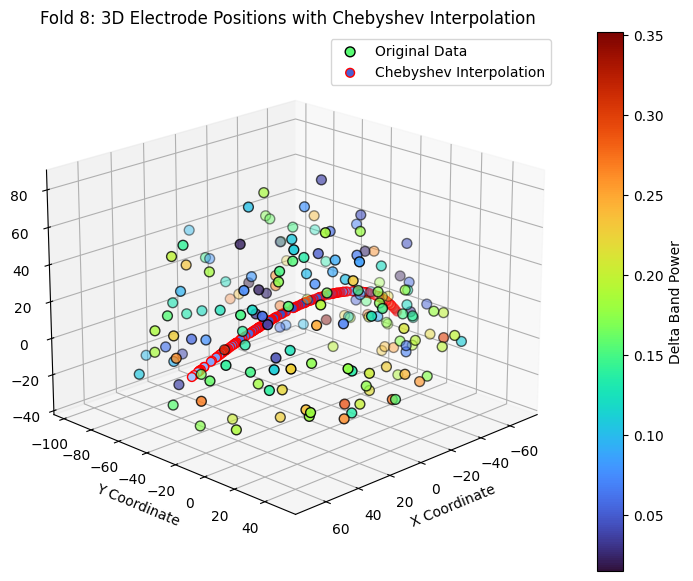


=== Fold 9 ===
MSE  : 0.0040
MAE  : 0.0526
RMSE : 0.0633
R²   : -0.0153


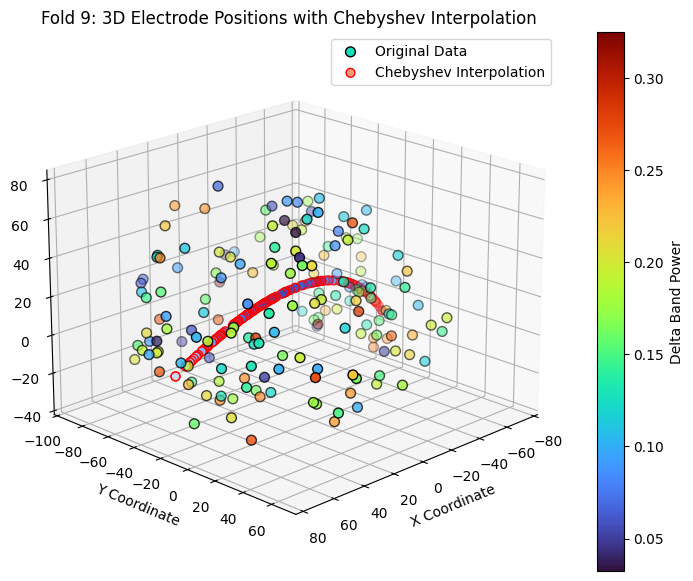


=== Fold 10 ===
MSE  : 0.0046
MAE  : 0.0568
RMSE : 0.0682
R²   : 0.0071


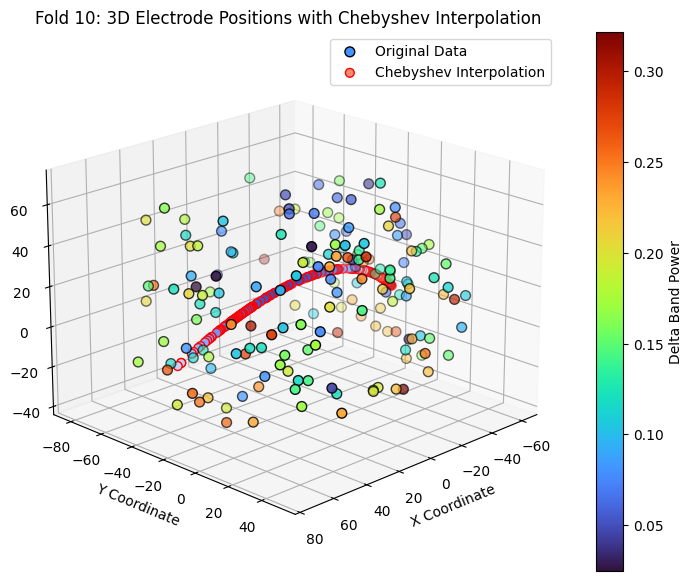


=== Final Evaluation Across 10 Folds ===
Mean MSE  : 0.0048 ± 0.0004
Mean MAE  : 0.0570 ± 0.0025
Mean RMSE : 0.0692 ± 0.0031
Mean R²   : 0.0007 ± 0.0096

T-test between MSE and MAE across folds:
T-statistic: -75.0790, P-value: 0.0000
Significant difference found (p < 0.05), suggesting MSE and MAE distributions are different.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from numpy.polynomial.chebyshev import Chebyshev
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from scipy.stats import ttest_rel  # T-test for paired samples

# Load dataset
samples = np.load('coords.npy')  # 3D electrode coordinates
band_powers = np.load('band_powers.npy', allow_pickle=True).item()  # Frequency band power data

# Convert to NumPy arrays to avoid indexing issues
X = np.array(samples[:, 0])
Y = np.array(samples[:, 1])
Z = np.array(samples[:, 2])
delta_powers = np.array(band_powers['Delta'])  # Ensure it's a NumPy array

# Define KFold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Function to compute evaluation metrics
def compute_metrics(true_values, predicted_values):
    """Compute evaluation metrics: MSE, MAE, RMSE, R²."""
    mse = mean_squared_error(true_values, predicted_values)
    mae = mean_absolute_error(true_values, predicted_values)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_values, predicted_values)
    return mse, mae, rmse, r2

# Store evaluation metrics
mse_scores = []
mae_scores = []
rmse_scores = []
r2_scores = []

# Perform 10-fold cross-validation
fold = 1
for train_index, test_index in kf.split(X):
    print(f"\n=== Fold {fold} ===")

    # Split data into training and testing sets
    X_train, X_test = X[train_index], X[test_index]
    Y_train, Y_test = Y[train_index], Y[test_index]
    Z_train, Z_test = Z[train_index], Z[test_index]
    Delta_train, Delta_test = delta_powers[train_index], delta_powers[test_index]

    # Sort X_train to ensure monotonicity for Chebyshev fitting
    sort_idx = np.argsort(X_train)
    X_train = X_train[sort_idx]
    Y_train = Y_train[sort_idx]
    Z_train = Z_train[sort_idx]
    Delta_train = Delta_train[sort_idx]

    # Fit Chebyshev polynomials for Y, Z, and Delta band power
    chebyshev_y = Chebyshev.fit(X_train, Y_train, deg=2)
    chebyshev_z = Chebyshev.fit(X_train, Z_train, deg=2)
    chebyshev_delta = Chebyshev.fit(X_train, Delta_train, deg=2)

    # Interpolate values for test X positions
    Y_interp = chebyshev_y(X_test)
    Z_interp = chebyshev_z(X_test)
    Delta_interp = chebyshev_delta(X_test)

    # Compute metrics for this fold
    mse, mae, rmse, r2 = compute_metrics(Delta_test, Delta_interp)

    # Store scores
    mse_scores.append(mse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    # Print evaluation metrics
    print(f"MSE  : {mse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    # Plot 3D interpolation result
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Original test data points
    sc = ax.scatter(X_test, Y_test, Z_test, c=Delta_test, cmap='turbo', label="Original Data", s=50, edgecolor='k')

    # Interpolated test data points
    sc_interp = ax.scatter(X_test, Y_interp, Z_interp, c=Delta_interp, cmap='coolwarm', label="Chebyshev Interpolation", s=40, edgecolor='r')

    # Color bar
    cbar = plt.colorbar(sc)
    cbar.set_label('Delta Band Power')

    # Axis labels
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_zlabel('Z Coordinate')
    ax.set_title(f'Fold {fold}: 3D Electrode Positions with Chebyshev Interpolation')

    # Show legend
    ax.legend()

    # Adjust view angle
    ax.view_init(elev=20, azim=45)

    # Show the plot
    plt.show()

    fold += 1

# Perform t-test to compare MSE and MAE scores across folds
t_stat, p_value = ttest_rel(mse_scores, mae_scores)  # Using paired t-test

# Print final evaluation
print("\n=== Final Evaluation Across 10 Folds ===")
print(f"Mean MSE  : {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")
print(f"Mean MAE  : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"Mean RMSE : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"Mean R²   : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")

# Print t-test results
print(f"\nT-test between MSE and MAE across folds:")
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

# Interpretation of t-test
if p_value < 0.05:
    print("Significant difference found (p < 0.05), suggesting MSE and MAE distributions are different.")
else:
    print("No significant difference found (p >= 0.05), suggesting MSE and MAE distributions are similar.")



=== Fold 1 ===
MSE  : 0.0046
MAE  : 0.0565
RMSE : 0.0679
R²   : 0.0161


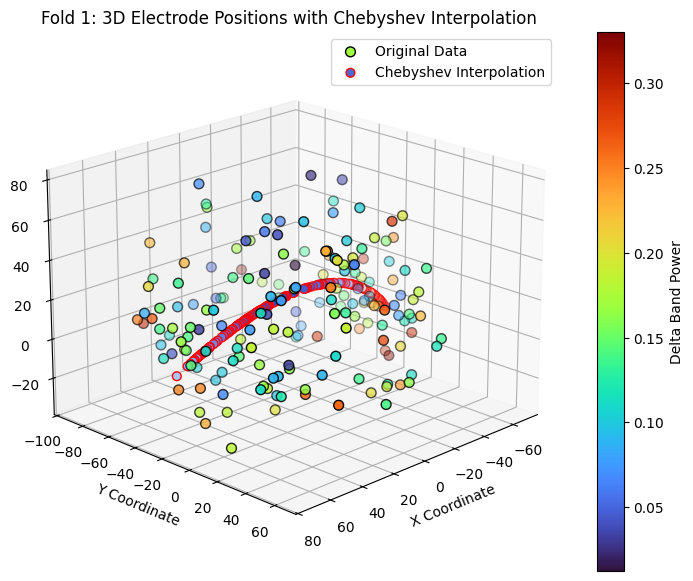


=== Fold 2 ===
MSE  : 0.0053
MAE  : 0.0593
RMSE : 0.0729
R²   : 0.0013


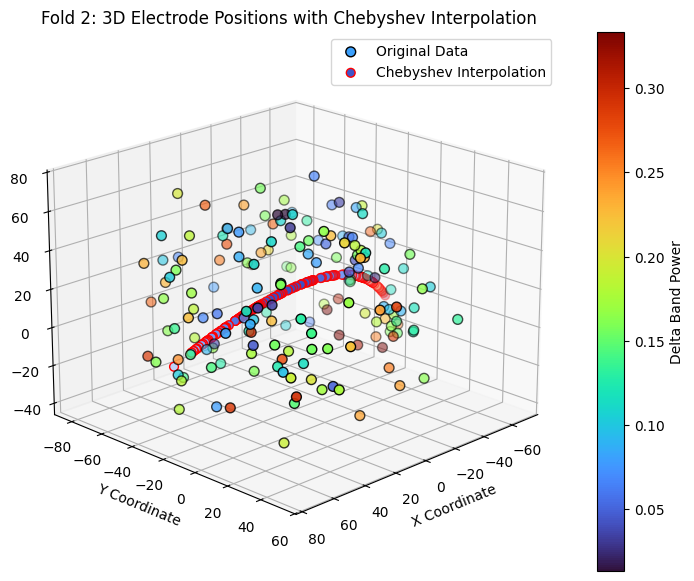


=== Fold 3 ===
MSE  : 0.0053
MAE  : 0.0606
RMSE : 0.0729
R²   : -0.0009


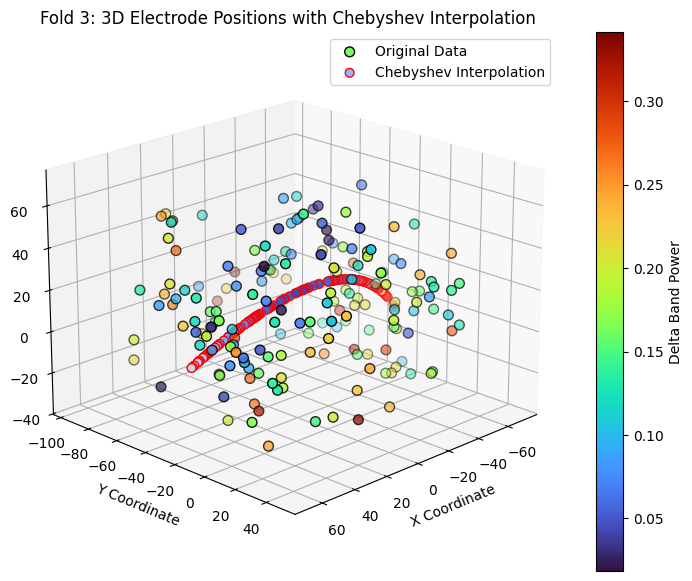


=== Fold 4 ===
MSE  : 0.0042
MAE  : 0.0530
RMSE : 0.0647
R²   : 0.0050


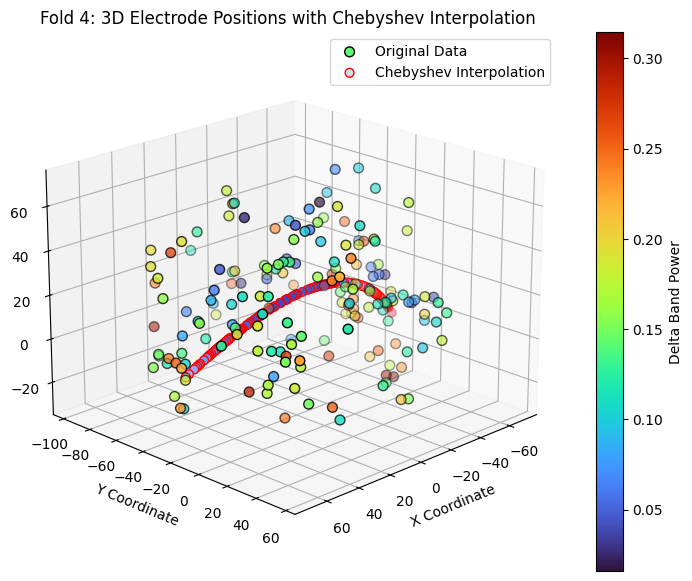


=== Fold 5 ===
MSE  : 0.0048
MAE  : 0.0559
RMSE : 0.0691
R²   : -0.0095


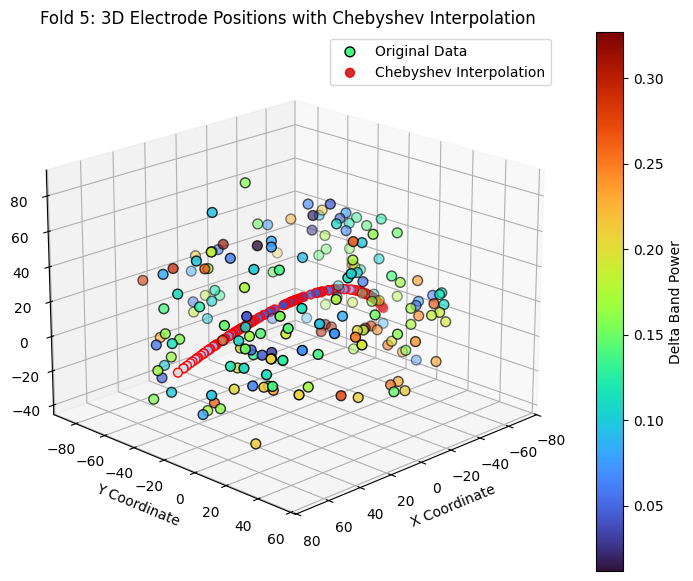


=== Fold 6 ===
MSE  : 0.0049
MAE  : 0.0581
RMSE : 0.0698
R²   : 0.0012


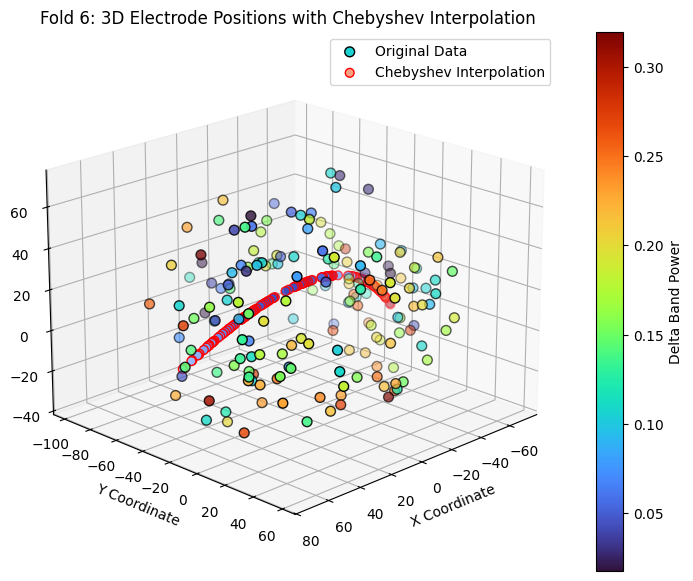


=== Fold 7 ===
MSE  : 0.0051
MAE  : 0.0590
RMSE : 0.0716
R²   : -0.0103


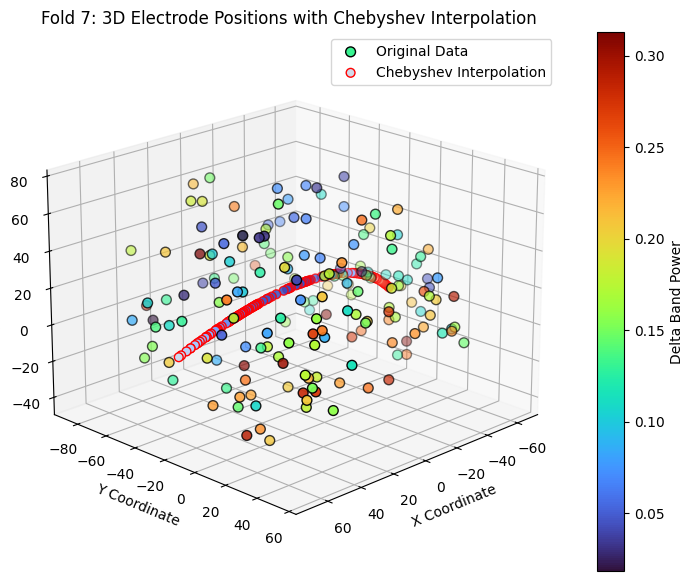


=== Fold 8 ===
MSE  : 0.0051
MAE  : 0.0583
RMSE : 0.0711
R²   : 0.0123


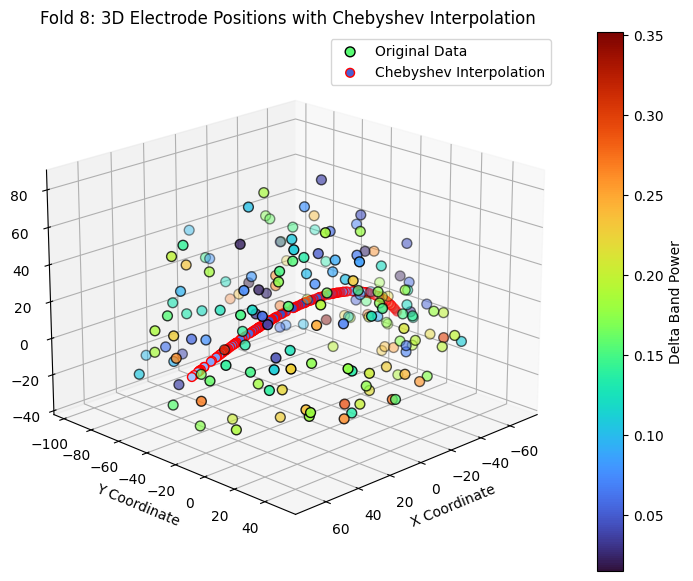


=== Fold 9 ===
MSE  : 0.0040
MAE  : 0.0526
RMSE : 0.0633
R²   : -0.0153


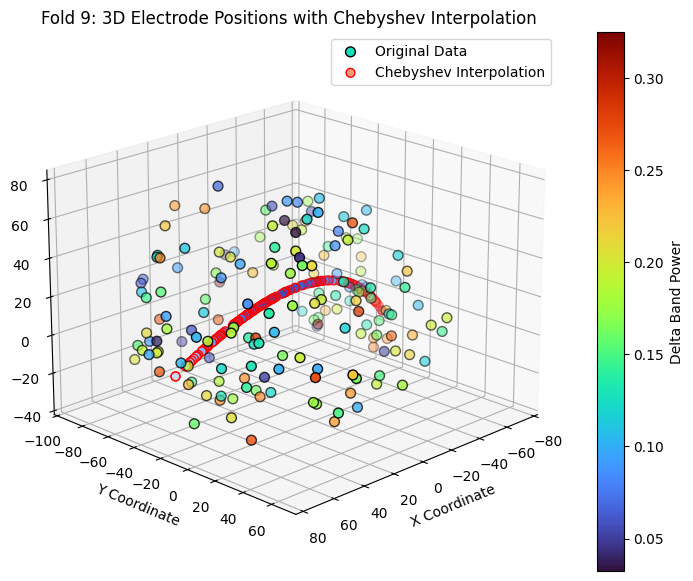


=== Fold 10 ===
MSE  : 0.0046
MAE  : 0.0568
RMSE : 0.0682
R²   : 0.0071


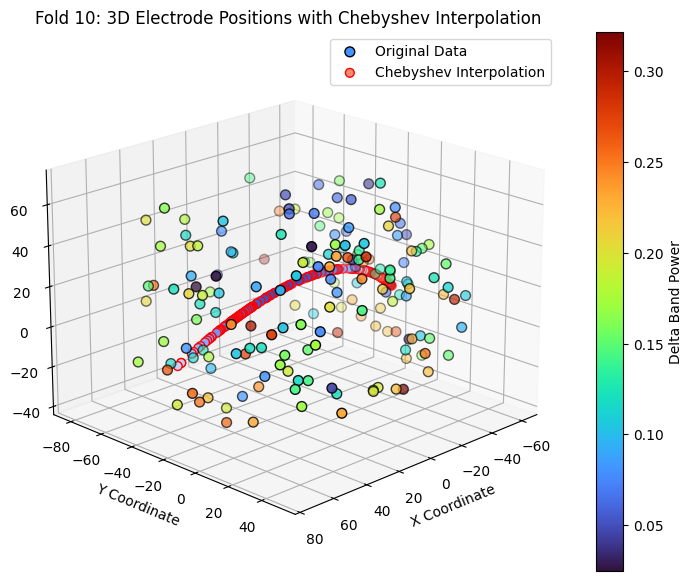


=== Final Evaluation Across 10 Folds ===
Mean MSE  : 0.0048 ± 0.0004
Mean MAE  : 0.0570 ± 0.0025
Mean RMSE : 0.0692 ± 0.0031
Mean R²   : 0.0007 ± 0.0096


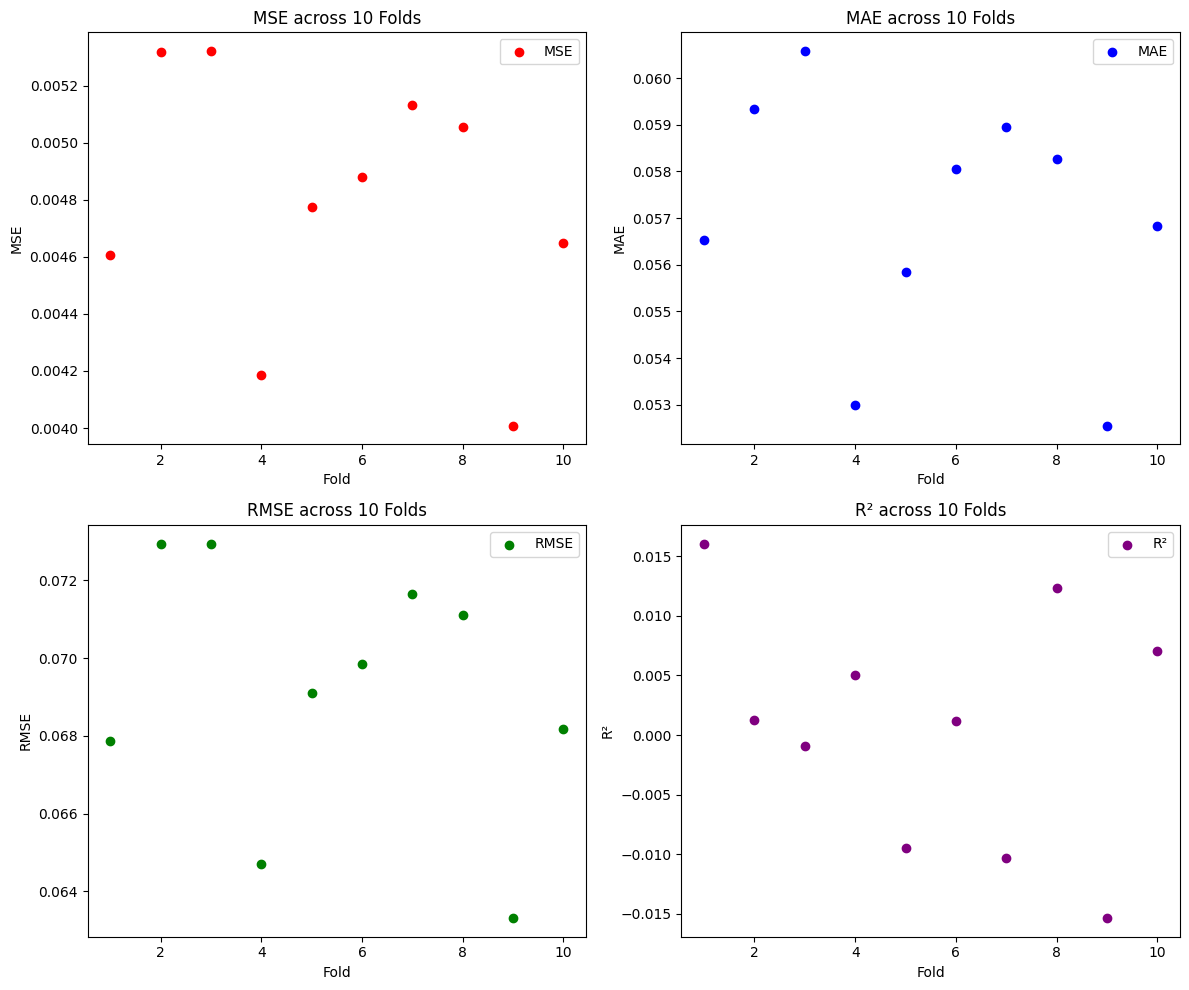


T-test between MSE and MAE across folds:
T-statistic: -75.0790, P-value: 0.0000
Significant difference found (p < 0.05), suggesting MSE and MAE distributions are different.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from numpy.polynomial.chebyshev import Chebyshev
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from scipy.stats import ttest_rel  # T-test for paired samples

# ✅ 1️⃣ Load dataset
samples = np.load('coords.npy')  # 3D electrode coordinates
band_powers = np.load('band_powers.npy', allow_pickle=True).item()  # Frequency band power data

# ✅ 2️⃣ Convert to NumPy arrays to avoid indexing issues
X = np.array(samples[:, 0])
Y = np.array(samples[:, 1])
Z = np.array(samples[:, 2])
delta_powers = np.array(band_powers['Delta'])  # Ensure it's a NumPy array

# ✅ 3️⃣ Define KFold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# ✅ 4️⃣ Function to compute evaluation metrics
def compute_metrics(true_values, predicted_values):
    """Compute MSE, MAE, RMSE, R²."""
    mse = mean_squared_error(true_values, predicted_values)
    mae = mean_absolute_error(true_values, predicted_values)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_values, predicted_values)
    return mse, mae, rmse, r2

# ✅ 5️⃣ Store evaluation metrics
mse_scores = []
mae_scores = []
rmse_scores = []
r2_scores = []

# ✅ 6️⃣ Perform 10-fold cross-validation
fold = 1
for train_index, test_index in kf.split(X):
    print(f"\n=== Fold {fold} ===")

    # Split data into training and testing sets
    X_train, X_test = X[train_index], X[test_index]
    Y_train, Y_test = Y[train_index], Y[test_index]
    Z_train, Z_test = Z[train_index], Z[test_index]
    Delta_train, Delta_test = delta_powers[train_index], delta_powers[test_index]

    # Ensure X_train is sorted for Chebyshev fitting
    sort_idx = np.argsort(X_train)
    X_train = X_train[sort_idx]
    Y_train = Y_train[sort_idx]
    Z_train = Z_train[sort_idx]
    Delta_train = Delta_train[sort_idx]

    # Fit Chebyshev polynomials
    chebyshev_y = Chebyshev.fit(X_train, Y_train, deg=2)
    chebyshev_z = Chebyshev.fit(X_train, Z_train, deg=2)
    chebyshev_delta = Chebyshev.fit(X_train, Delta_train, deg=2)

    # Interpolate test values
    Y_interp = chebyshev_y(X_test)
    Z_interp = chebyshev_z(X_test)
    Delta_interp = chebyshev_delta(X_test)

    # Compute metrics
    mse, mae, rmse, r2 = compute_metrics(Delta_test, Delta_interp)

    # Store results
    mse_scores.append(mse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    # Print results
    print(f"MSE  : {mse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    # 📌 7️⃣ Plot 3D interpolation result
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Original test data points
    sc = ax.scatter(X_test, Y_test, Z_test, c=Delta_test, cmap='turbo', label="Original Data", s=50, edgecolor='k')

    # Interpolated test data points
    sc_interp = ax.scatter(X_test, Y_interp, Z_interp, c=Delta_interp, cmap='coolwarm', label="Chebyshev Interpolation", s=40, edgecolor='r')

    # Color bar
    cbar = plt.colorbar(sc)
    cbar.set_label('Delta Band Power')

    # Axis labels
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_zlabel('Z Coordinate')
    ax.set_title(f'Fold {fold}: 3D Electrode Positions with Chebyshev Interpolation')

    # Show legend
    ax.legend()
    ax.view_init(elev=20, azim=45)
    plt.show()

    fold += 1

# ✅ 8️⃣ Perform t-test to compare MSE and MAE
t_stat, p_value = ttest_rel(mse_scores, mae_scores)

# ✅ 9️⃣ Print final evaluation results
print("\n=== Final Evaluation Across 10 Folds ===")
print(f"Mean MSE  : {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")
print(f"Mean MAE  : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"Mean RMSE : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"Mean R²   : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")

# ✅ 10️⃣ Scatter plot visualization of evaluation metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# MSE Plot
axes[0, 0].scatter(range(1, 11), mse_scores, color='red', label='MSE')
axes[0, 0].set_title('MSE across 10 Folds')
axes[0, 0].set_xlabel('Fold')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].legend()

# MAE Plot
axes[0, 1].scatter(range(1, 11), mae_scores, color='blue', label='MAE')
axes[0, 1].set_title('MAE across 10 Folds')
axes[0, 1].set_xlabel('Fold')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend()

# RMSE Plot
axes[1, 0].scatter(range(1, 11), rmse_scores, color='green', label='RMSE')
axes[1, 0].set_title('RMSE across 10 Folds')
axes[1, 0].set_xlabel('Fold')
axes[1, 0].set_ylabel('RMSE')
axes[1, 0].legend()

# R² Plot
axes[1, 1].scatter(range(1, 11), r2_scores, color='purple', label='R²')
axes[1, 1].set_title('R² across 10 Folds')
axes[1, 1].set_xlabel('Fold')
axes[1, 1].set_ylabel('R²')
axes[1, 1].legend()

# Adjust layout
plt.tight_layout()
plt.show()

# ✅ 11️⃣ Print t-test results
print(f"\nT-test between MSE and MAE across folds:")
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

# ✅ Interpret t-test results
if p_value < 0.05:
    print("Significant difference found (p < 0.05), suggesting MSE and MAE distributions are different.")
else:
    print("No significant difference found (p >= 0.05), suggesting MSE and MAE distributions are similar.")


new dataset: expresson.npy express_coords.npy